# Static structures tutorial

Sometimes you don't want to wait for gigayears of evolution. You just want to know what a planet of a given mass, entropy, and composition looks like right now: a quick interior profile, a mass-radius point, a sanity check on an EOS choice before you commit to a full run. `ORCHARD` can do this directly from a notebook, and each converged structure takes a fraction of a second.

The simple way is the `static.py` wrapper, which this tutorial uses throughout. One call, `build()`, returns a converged hydrostatic structure as a single object. The two lower-level functions it wraps (`initialize_grid()` from `initial.py` and `hydrostatic_equilibrium()` from `hydrostatic.py`) are shown at the end for anyone who wants to drive them by hand.

**NOTE**: This is "library mode". There is no config file on disk, no `models/` output folder, and nothing is saved. Everything lives in your notebook session.

## `static.py` example: Simple Jupiter static adiabatic model

The first thing `ORCHARD`'s module solvers do is read the configuration parameter files. That is when the EOS tables are imported and when parameters like `[core].mass_core` and the composition-profile shapes are set. Driving the solvers by hand therefore means mutating `utils.common.config` in exactly the right order, and restarting the kernel whenever an import-frozen parameter changes.

`static.build()` handles the static initialization for static models, such as:

- total mass, entropy, `Y`, `Z`, `f_rock`, and `N` are plain function arguments, so scans over them are cheap (no reloads),
- import-frozen parameters (`mass_core`, `mass_core_fe`, `mantle_comp`, profile shapes, `rotation`, the EOS choices, ...) are keyword arguments too; when one changes, the wrapper reloads the solver modules for you instead of making you restart the kernel. The EOS objects are cached across reloads, so this adds almost nothing,
- anything else can be set through `overrides={section: {key: value}}`, the same names as in a config file,
- every call starts from the pristine `parameters_default.ini` state, so a fuzzy-core `z_profile` or a `rotation=True` from one build never leaks into the next one.

`build()` also picks the first guess for the Henyey relaxation automatically, which is where nearly all of the runtime used to go. The RK4 shooting builder (`rk4_initial.py`) costs about 20 seconds because it re-integrates the structure for every bisection step, while the relaxation itself takes about 0.1 seconds. Since both first guesses relax to the same structure (they agree to ~$10^{-10}$ in radius), `build()` tries the cheap rescaled-isentrope guess first and only falls back to RK4 if that fails to converge. You can pin either one with `rk4_initial=True` or `False`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from static import build          # first build triggers 'Loading EOS ...'
from utils import const

# 1 M_Jup, cold Jupiter-like adiabat, 10 M_Earth compact core
jup = build(M_MJup=1.0, S=6.5, Y=0.277, Z=0.02, mass_core=10.0)
print(jup)

Loading EOS ...


Ready!
StaticModel: M = 317.83 M_E (1.000 M_J), R = 1.0301 R_J (11.291 R_E), P_c = 70.7 Mbar, T_c = 29832 K, 104 iterations


## Reading the result

A few conventions to keep in mind (they trip up everyone at least once):

- Arrays run outside to inside. Index 0 is the surface and index $N-1$ is the center, so `jup.r_b[0]` is the planetary radius and `jup.p[-1]` is the central pressure.
- Cell-centered arrays (`p`, `rho`, `temp`, `S`, `Y`, `Z`, `f_rock`) have length $N$. Boundary arrays (`r_b`, `m_b`) have length $N+1$, with `m_b[0]` equal to the total mass.
- `jup.kcore` is the index of the envelope-core boundary; cells with $k \geq$ `kcore` are the rocky interior. `jup.kcore_fe` marks the iron sub-core, if any.
- `jup.j2n` unpacks as `[J2, J4, J6, J8, oblateness, R_eq, R_pol, MoI]`, with the $J_n$ scaled by $10^6$. These are zeros unless you build with `rotation=True, tof=True` (we will, in the fuzzy-core example below).

`build()` also gives you shortcut properties (`radius_rj`, `radius_re`, `mass_me`, `j2_ppm`, `j4_ppm`) and a quick-look figure:

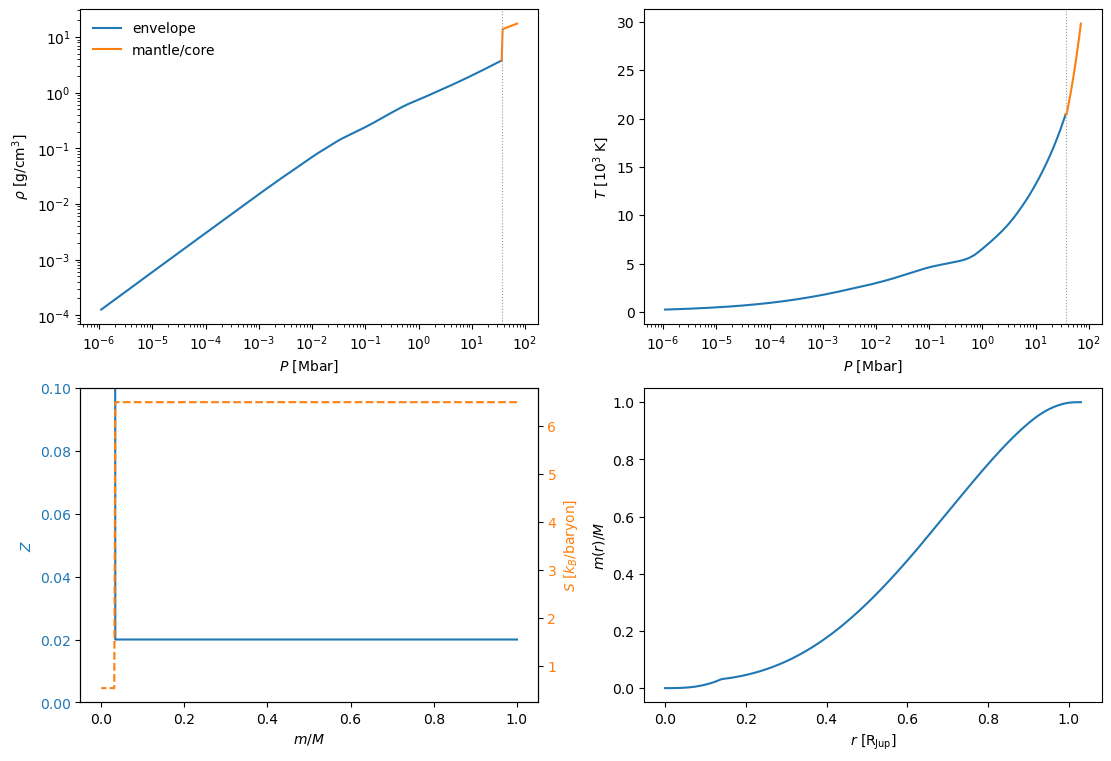

In [2]:
jup.plot();

The envelope rides the $S = 6.5$ k$_B$/baryon adiabat down to the envelope-core boundary (dotted line), where the density jumps onto the rocky-core EOS. The entropy trace is flat in the envelope, since this is a homogeneous, adiabatic model.

## Varying the composition

Mass, entropy, helium, and metallicity are plain arguments, so we can scan them without any reloads. Let's raise the envelope metallicity and watch the structure compress. More metals at fixed entropy means a denser, more compact planet.

Loading EOS ...
Ready!
Loading EOS ...
Ready!


Loading EOS ...
Ready!


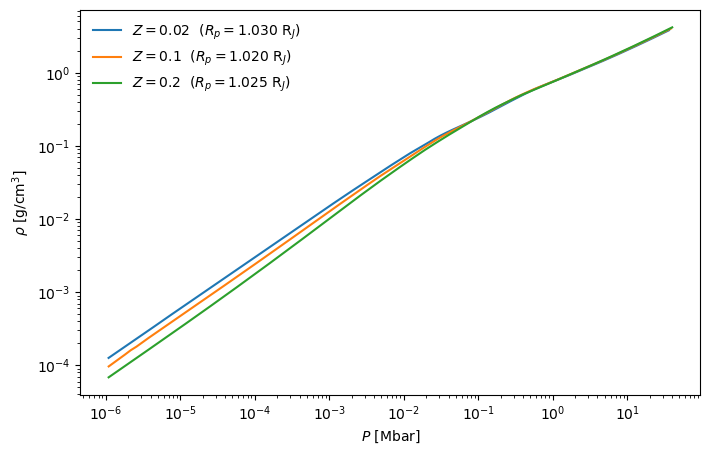

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

for z in [0.02, 0.10, 0.20]:
    m = build(M_MJup=1.0, S=6.5, Y=0.277, Z=z, mass_core=10.0)
    ax.plot(m.p[:m.kcore] * 1e-12, m.rho[:m.kcore],
            label=f'$Z = {z}$  ($R_p = {m.radius_rj:.3f}$ R$_J$)')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$P$ [Mbar]'); ax.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax.legend(frameon=False)
plt.show()

## A static mass-radius curve

My favorite use of static structures is a mass-radius relation in a couple of minutes. We fix the entropy and composition and scan the total mass. Remember that these are radii at the chosen entropy. A hot (high-$S$) planet is puffy, so think of each point as a snapshot early in the cooling history, not a 4.5-Gyr radius. Lower `S` for colder, older-looking planets, or run the real evolution (see `tutorial_superjupiters.ipynb`) for radii at a given age. These models are coreless, unlike the 10 M$_\oplus$-core Jupiter above.

**NOTE**: A compact core in a massive planet can push the mantle EOS past its tabulated range. The default `mg2sio4` (ANEOS) mantle is tabulated to $10^4$ GPa, which a 1 M$_J$ model with a 10 M$_\oplus$ core stays under (its centre reaches about 7000 GPa) but a 5 M$_J$ model does not: its core would sit near $1.5 \times 10^5$ GPa. `ORCHARD` refuses to return such a structure and tells you so, rather than handing back an extrapolated one. If you do want a cored super-Jupiter, use the post-perovskite mantle instead, which stays physical to about $1.5\times10^5$ GPa:

```python
build(M_MJup=5.0, S=6.5, Y=0.277, Z=0.02, mass_core=10.0,
      mantle_comp='mgsio3', overrides={"core": {"eos_mantle": "PPV_2"}})
```

Loading EOS ...
Ready!
 0.3 M_J -> 0.9789 R_J (110 iterations)
Loading EOS ...
Ready!
 1.0 M_J -> 1.0509 R_J (111 iterations)
Loading EOS ...
Ready!


Loading EOS ...


Ready!
 2.0 M_J -> 1.0822 R_J (156 iterations)
Loading EOS ...
Ready!
Loading EOS ...


Ready!
 5.0 M_J -> 1.0763 R_J (210 iterations)


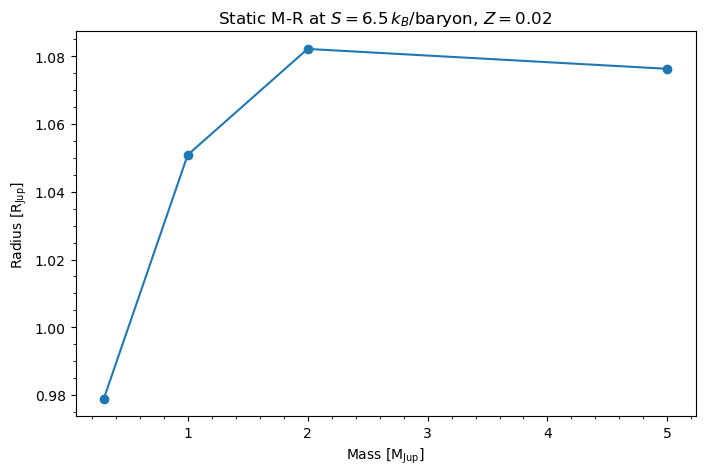

In [4]:
masses_mj = [0.3, 1.0, 2.0, 5.0]
radii_rj = []

for mmj in masses_mj:
    # Coreless: above ~1 M_J a compact core sits at pressures the default
    # mg2sio4 mantle EOS does not cover (see the note below).
    m = build(M_MJup=mmj, S=6.5, Y=0.277, Z=0.02,
              mass_core=0.0, mass_core_fe=0.0)
    radii_rj.append(m.radius_rj)
    print(f"{mmj:4.1f} M_J -> {m.radius_rj:.4f} R_J ({m.niter} iterations)")

plt.figure(figsize=(8, 5))
plt.plot(masses_mj, radii_rj, 'o-')
plt.xlabel(r'Mass [M$_{\rm Jup}$]')
plt.ylabel(r'Radius [R$_{\rm Jup}$]')
plt.title(r'Static M-R at $S = 6.5\,k_B$/baryon, $Z = 0.02$')
plt.minorticks_on()
plt.show()

The familiar flat top of the giant-planet M-R relation emerges already in these static models. Above roughly a Jupiter mass, added mass compresses the interior (H/He is close to an $n \approx 1$ polytrope) instead of growing the radius.

## Sub-Neptunes and super-Earths

Static structures are not just for gas giants. A sub-Neptune is a rocky interior with a thin H-He-Z envelope, and a bare super-Earth is all mantle and iron core. Two things to know:

- `mass_core` and `mass_core_fe` are import-frozen, so changing them makes `build()` reload the solver modules. You will see 'Loading EOS ...' again; the EOS objects are cached across reloads, so this is quick.
- For a bare planet we set the mantle entropy directly (`env_s_start = False`), since there is no envelope to inherit it from.

Loading EOS ...
Ready!


StaticModel: M = 6.00 M_E (0.019 M_J), R = 0.3292 R_J (3.608 R_E), P_c = 22.1 Mbar, T_c = 13218 K, 105 iterations
Loading EOS ...
Ready!
StaticModel: M = 3.00 M_E (0.009 M_J), R = 0.1296 R_J (1.420 R_E), P_c = 10.9 Mbar, T_c = 12073 K, 80 iterations


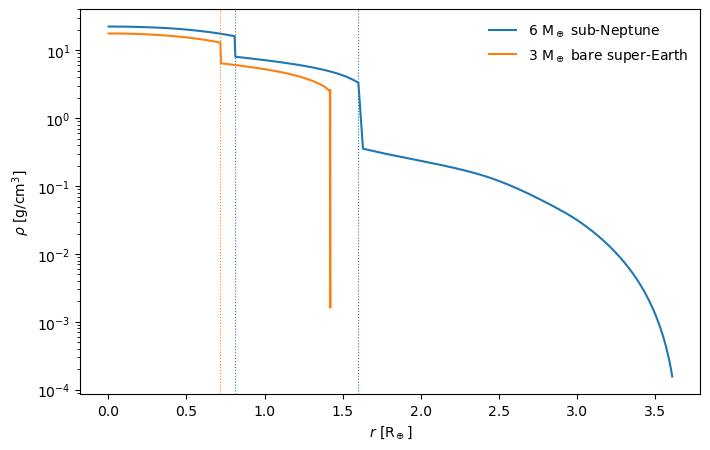

In [5]:
# 6 M_Earth sub-Neptune: 10% H-He-Z envelope, 2:1 mantle-to-iron interior
subnep = build(M_Mearth=6.0, S=6.0, Y=0.277, Z=0.05,
               mass_core=5.4, mass_core_fe=1.8)
print(subnep)

# 3 M_Earth bare super-Earth: no envelope at all
searth = build(M_Mearth=3.0, S=6.0, mass_core=3.0, mass_core_fe=1.0,
               overrides={"hydrostatic_equilibrium": {"env_s_start": "False"},
                          "core": {"mantle_entropy": "0.55"}})
print(searth)

fig, ax = plt.subplots(figsize=(8, 5))
for m, label in [(subnep, '6 M$_\\oplus$ sub-Neptune'),
                 (searth, '3 M$_\\oplus$ bare super-Earth')]:
    r_re = m.r_b[:-1] / const.rearth
    line, = ax.plot(r_re, m.rho, label=label)
    for k in (m.kcore, m.kcore_fe):          # envelope-mantle, mantle-iron
        if 0 < k < len(m.p):
            ax.axvline(m.r_b[k] / const.rearth, color=line.get_color(),
                       lw=0.8, ls=':')
ax.set_yscale('log')
ax.set_xlabel(r'$r$ [R$_\oplus$]'); ax.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax.legend(frameon=False)
plt.show()

The dotted lines mark the envelope-mantle and mantle-iron boundaries. The sub-Neptune's thin envelope inflates the radius well past the bare planet's, which is the whole story of the sub-Neptune population in one figure. For the evolution of these objects (cooling, mantle solidification, melt fractions), see `tutorial_subneptunes_superearths.ipynb`.

## A fuzzy-core Jupiter (MH24-like)

*Juno* gravity data suggest Jupiter's heavy elements are not in a compact core but spread over a dilute ("fuzzy") core extending far into the envelope. Militzer & Hubbard (2024) fit interior models of this kind to the *Juno* harmonics. Here we build a static ORCHARD structure with an MH24-like $Z(m)$ profile: the breakpoints below are read off one of their dilute-core models (their model `out10969`), with $Z \approx 0.18$ over the inner third of the mass, grading down to the envelope value near half the mass.

Composition profiles go in as `(coords, values)` breakpoints in normalized mass, center (0) to surface (1), exactly like `z_init_coords` / `z_init_values` in a config file. We also switch on rotation and the fourth-order Theory of Figures (`rotation=True, tof=True`), so the model comes back with gravity harmonics we can compare against MH24's static values ($J_2 = 14696.4$ ppm, $J_4 = -586.8$ ppm for that model).

**NOTE**: We keep an ORCHARD adiabat ($S = 7$ k$_B$/baryon) and protosolar $Y$ rather than MH24's exact barotrope and helium-rain structure, so the harmonics land close to, but not on, their values. Matching $J_2$ at the percent level with a different EOS and thermal profile is the expected outcome, not a failure.

Loading EOS ...
Ready!


StaticModel: M = 317.83 M_E (1.000 M_J), R = 1.1200 R_J (12.277 R_E), P_c = 23.4 Mbar, T_c = 38882 K, 490 iterations, J2 = 14097.8 ppm
J2 =  14097.8 ppm   (MH24 out10969 static: 14696.4)
J4 =   -515.0 ppm   (MH24 out10969 static:  -586.8)


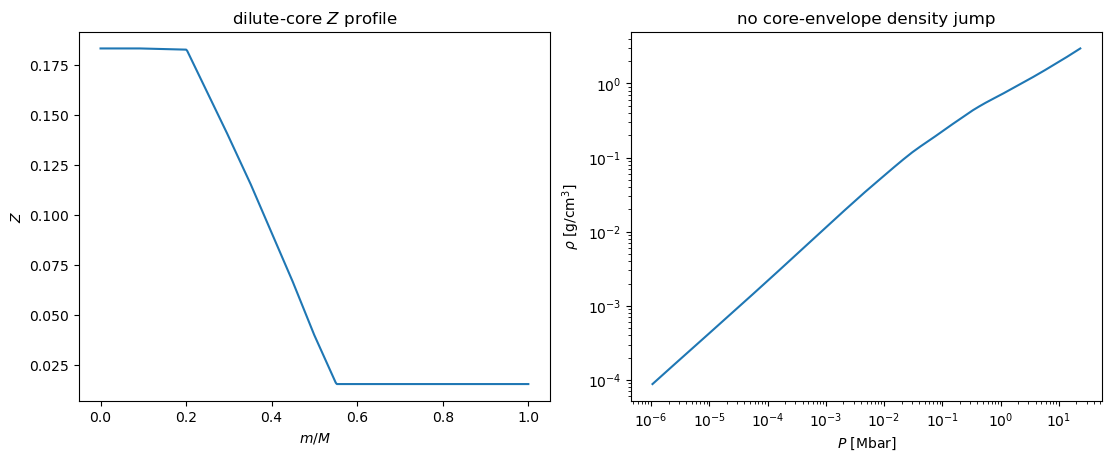

In [6]:
# Z(m) breakpoints read off the MH24 dilute-core model out10969
mh24_coords = [0.0, 0.10, 0.20, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.85, 1.0]
mh24_z      = [0.1831, 0.1831, 0.1825, 0.1383, 0.1152, 0.0905, 0.0657,
               0.0392, 0.0156, 0.0156, 0.0156, 0.0156, 0.0156]

fuzzy = build(M_MJup=1.0, S=7.0, Y=0.277, Z=0.0156,
              mass_core=0.0, mass_core_fe=0.0,          # coreless: all Z is dilute
              z_profile=(mh24_coords, mh24_z),
              rotation=True, tof=True, period=35730, c_moi=0.26393)
print(fuzzy)
print(f"J2 = {fuzzy.j2_ppm:8.1f} ppm   (MH24 out10969 static: 14696.4)")
print(f"J4 = {fuzzy.j4_ppm:8.1f} ppm   (MH24 out10969 static:  -586.8)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
m_norm = fuzzy.m_b[:-1] / fuzzy.m_b[0]
ax1.plot(m_norm, fuzzy.Z)
ax1.set_xlabel(r'$m/M$'); ax1.set_ylabel(r'$Z$')
ax1.set_title('dilute-core $Z$ profile')
ax2.plot(fuzzy.p * 1e-12, fuzzy.rho)
ax2.set_xscale('log'); ax2.set_yscale('log')
ax2.set_xlabel(r'$P$ [Mbar]'); ax2.set_ylabel(r'$\rho$ [g/cm$^3$]')
ax2.set_title('no core-envelope density jump')
plt.show()

The density profile is continuous all the way to the center: there is no compact core to jump onto, just the smooth $Z$ gradient. This is the static starting point for the inhomogeneous evolution models in `tutorial_inhomogeneous_evolution.ipynb` and `tutorial_solarsystem_planets.ipynb`, where gradients like this one erode (or survive) over Gyrs. Varying the entropy profile via `s_profile` in `build` would get closer to the MH24 values. This is left as an exercise to the reader.

## Under the hood

`build()` is sugar over two calls, and you can drive them yourself if you need something the wrapper does not expose:

```python
from utils import common, const
c = common.config
# ... mutate c BEFORE the imports below; those reads happen at import time ...
from initial import initialize_grid
from hydrostatic import hydrostatic_equilibrium

r_b0, p0, m_b, dm, S, Y, Z, f_rock, kcore, kcore_fe = initialize_grid(
    N, M_planet, S_ini, Y_ini, Z_ini, f_rock_ini)
kcore    = N if kcore    == -1 else kcore     # -1 sentinel = no boundary
kcore_fe = N if kcore_fe == -1 else kcore_fe
r_b, p, rho, temp, S, g, omega, j2n, shapes, niter = hydrostatic_equilibrium(
    S, np.log(r_b0), np.log(p0), m_b, Y, Z, f_rock, kcore, kcore_fe,
    omega_prev=0.0, time_sc=0.0, logt_old=np.zeros_like(S), init=True)
```

If you go this route, the order of operations is on you: mutate the config first, import second, and restart the kernel (or reload `initial` and `hydrostatic`) when an import-frozen parameter changes. That bookkeeping is exactly what `static.py` automates.

`initialize_grid()` needs a starting structure for the Henyey relaxation to polish. With `rk4_initial = True`, `ORCHARD` builds it by RK4 shooting, integrating the structure equations inward while bisecting on the central pressure until the surface boundary condition is met (`rk4_initial.py`). With `rk4_initial = False`, it instead rescales a stored $S = 9$ Jupiter isentrope, which is fine near a Jupiter mass and cruder elsewhere. Either way, the relaxation converges to the same hydrostatic answer; a better first guess just gets there in fewer iterations.

For evolution runs that difference hardly matters, since the initial structure is built once and then integrated for gigayears. For static work it is the whole cost of the calculation, which is why `build()` prefers the cheap guess (see above). The other knobs worth knowing, if a model is slow or stubborn:

- `alpha` sets the Newton damping (`hse_alpha_init`, default 0.4). Raising it to 0.7-0.85 typically halves the iteration count with an identical answer; too high and the iteration can walk off to NaN.
- `tol` sets the convergence tolerance (`tol_hydro`, default $10^{-10}$). $10^{-8}$ saves about 20% of the iterations and gives the same structure to six digits.
- `guess=<previous model>` warm-starts the relaxation from an already converged structure, which cuts the iteration count in a scan over a smoothly varying parameter. With the cheap first guess this is a minor gain, but it helps when you have pinned `rk4_initial=True`.
- `N` sets the resolution. Lower `N` is faster but coarser: the 1 M$_J$ model above moves by about 1.4% in radius between `N = 200` and `N = 500`.

**NOTE**: You can also get a static structure without writing any Python. Set `final_age` to a tiny value (e.g. `1e-9`) in a config file and run `evolution.py` normally. The run converges the initial structure, saves exactly one snapshot, and exits, giving you a `models/<config>/` folder you can load with `load_models` and `plot_class` like any other run. This is emergent behavior rather than a supported "static mode" flag, so treat it as the quick-and-dirty route.

## Exercises

1. Turn the sub-Neptune above into a small M-R curve: scan `M_Mearth` from 4 to 10 at fixed `mass_core=5.4`. The reload between calls is cheap (the EOS objects are cached).
2. Compare the CD21 and CMS19 H-He EOSes at fixed mass and entropy (`overrides={"equation_of_state": {"hhe_eos": "cms"}}`; the wrapper reloads for you). How much does the central temperature move?
3. Redo the giant-planet M-R curve at $S = 8.5$ k$_B$/baryon and overplot both. The gap between the two curves *is* the cooling contraction that the full evolution code integrates through time.
4. Steepen the MH24-like gradient (push the $Z$ plateau higher and the transition deeper) and watch what it does to $J_2$ and $J_4$.